# L2MapEngine — Mapping Analysis

Visual diagnostics for the L2 field mapping engine.  
Covers 2D (Quad8) and 3D (Hex8) cases with error maps, convergence studies, and engine comparisons.

**Prerequisites:** build the library first, then adjust `BUILD_DIR` below.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable
import time

# --- Adjust this path to your build output ---
BUILD_DIR = r"../build/python/Release"   # Windows MSVC
# BUILD_DIR = r"../build/python"          # Linux / macOS

sys.path.insert(0, BUILD_DIR)
import l2map_py

print(f"l2map_py loaded from {BUILD_DIR}")

l2map_py loaded from ../build/python/Release


## Mesh builders
Pure-Python helpers that mirror the C++ test helpers exactly.

In [2]:
def make_quad8_mesh(nx, ny, Lx=1.0, Ly=1.0, x0=0.0, y0=0.0):
    """
    Regular nx×ny grid of Quad8 elements on [x0,x0+Lx]×[y0,y0+Ly].
    Returns:
      nodes:    (N, 3)  — [id, x, y]  1-indexed
      elements: (M, 9)  — [id, n1..n8]  1-indexed
    """
    hx = Lx / nx
    hy = Ly / ny
    npts_x = 2 * nx + 1
    npts_y = 2 * ny + 1

    nodes = []
    nid = 1
    for j in range(npts_y):
        for i in range(npts_x):
            x = x0 + i * hx * 0.5
            y = y0 + j * hy * 0.5
            nodes.append([nid, x, y])
            nid += 1
    nodes = np.array(nodes, dtype=float)

    def nidx(ci, cj, di, dj):
        return (cj + dj) * npts_x + (ci + di) + 1  # 1-indexed

    elements = []
    eid = 1
    for ej in range(ny):
        for ei in range(nx):
            ci = 2 * ei
            cj = 2 * ej
            corners  = [nidx(ci,cj,0,0), nidx(ci,cj,2,0),
                        nidx(ci,cj,2,2), nidx(ci,cj,0,2)]
            midsides = [nidx(ci,cj,1,0), nidx(ci,cj,2,1),
                        nidx(ci,cj,1,2), nidx(ci,cj,0,1)]
            elements.append([eid] + corners + midsides)
            eid += 1
    elements = np.array(elements, dtype=float)
    return nodes, elements


def make_quad8_field(nodes, elements, f):
    """
    Evaluate f(x,y) at each Quad8 integration point.
    Returns field_data: (M*9, 3) — [elem_id, ipt_id, value]  1-indexed
    """
    gp = np.sqrt(0.6)
    nat_pts = [(xi, eta) for eta in [-gp, 0.0, gp] for xi in [-gp, 0.0, gp]]

    def shape(xi, eta):
        return np.array([
            -0.25*(1-xi)*(1-eta)*(1+xi+eta),
            -0.25*(1+xi)*(1-eta)*(1-xi+eta),
            -0.25*(1+xi)*(1+eta)*(1-xi-eta),
            -0.25*(1-xi)*(1+eta)*(1+xi-eta),
             0.5 *(1-xi**2)*(1-eta),
             0.5 *(1+xi)  *(1-eta**2),
             0.5 *(1-xi**2)*(1+eta),
             0.5 *(1-xi)  *(1-eta**2),
        ])

    node_xy = {int(row[0]): row[1:3] for row in nodes}
    rows = []
    for elem in elements:
        eid = int(elem[0])
        nids = elem[1:].astype(int)
        coords = np.array([node_xy[n] for n in nids])
        for ipt, (xi, eta) in enumerate(nat_pts):
            N = shape(xi, eta)
            x = N @ coords[:, 0]
            y = N @ coords[:, 1]
            rows.append([eid, ipt+1, f(x, y)])
    return np.array(rows, dtype=float)


def make_hex8_mesh(nx, ny, nz, Lx=1.0, Ly=1.0, Lz=1.0):
    """
    Regular nx×ny×nz grid of Hex8 elements on [0,Lx]×[0,Ly]×[0,Lz].
    Returns:
      nodes:    (N, 4)  — [id, x, y, z]  1-indexed
      elements: (M, 9)  — [id, n1..n8]   1-indexed
    """
    hx = Lx / nx
    hy = Ly / ny
    hz = Lz / nz

    nodes = []
    nid = 1
    for k in range(nz+1):
        for j in range(ny+1):
            for i in range(nx+1):
                nodes.append([nid, i*hx, j*hy, k*hz])
                nid += 1
    nodes = np.array(nodes, dtype=float)

    def nidx(i, j, k):
        return k*(nx+1)*(ny+1) + j*(nx+1) + i + 1  # 1-indexed

    elements = []
    eid = 1
    for ek in range(nz):
        for ej in range(ny):
            for ei in range(nx):
                elements.append([
                    eid,
                    nidx(ei,  ej,  ek  ), nidx(ei+1,ej,  ek  ),
                    nidx(ei+1,ej+1,ek  ), nidx(ei,  ej+1,ek  ),
                    nidx(ei,  ej,  ek+1), nidx(ei+1,ej,  ek+1),
                    nidx(ei+1,ej+1,ek+1), nidx(ei,  ej+1,ek+1),
                ])
                eid += 1
    elements = np.array(elements, dtype=float)
    return nodes, elements


def make_hex8_field(nodes, elements, f):
    """
    Evaluate f(x,y,z) at each Hex8 integration point (2×2×2 Gauss rule).
    Returns field_data: (M*8, 3) — [elem_id, ipt_id, value]  1-indexed
    """
    gp = 1.0 / np.sqrt(3.0)
    nat_pts = [(xi, eta, zeta)
               for zeta in [-gp, gp]
               for eta  in [-gp, gp]
               for xi   in [-gp, gp]]

    def shape(xi, eta, zeta):
        return 0.125 * np.array([
            (1-xi)*(1-eta)*(1-zeta), (1+xi)*(1-eta)*(1-zeta),
            (1+xi)*(1+eta)*(1-zeta), (1-xi)*(1+eta)*(1-zeta),
            (1-xi)*(1-eta)*(1+zeta), (1+xi)*(1-eta)*(1+zeta),
            (1+xi)*(1+eta)*(1+zeta), (1-xi)*(1+eta)*(1+zeta),
        ])

    node_xyz = {int(row[0]): row[1:4] for row in nodes}
    rows = []
    for elem in elements:
        eid = int(elem[0])
        nids = elem[1:].astype(int)
        coords = np.array([node_xyz[n] for n in nids])
        for ipt, (xi, eta, zeta) in enumerate(nat_pts):
            N = shape(xi, eta, zeta)
            x, y, z = N @ coords
            rows.append([eid, ipt+1, f(x, y, z)])
    return np.array(rows, dtype=float)


print("Mesh builders ready.")

Mesh builders ready.


---
## 1 — 2D Mapping: field map and error

Coarse Quad8 grid → fine Quad8 grid.  
Field: $f(x,y) = \sin(2\pi x)\cos(2\pi y)$ — non-linear, shows real approximation error.

In [3]:
# --- Build meshes ---
nx_c, ny_c = 10, 10
nx_f, ny_f = 20, 20

nodes_c, elems_c = make_quad8_mesh(nx_c, ny_c)
nodes_f, elems_f = make_quad8_mesh(nx_f, ny_f)

f2d = lambda x, y: np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

field_c = make_quad8_field(nodes_c, elems_c, f2d)

# --- Map ---
result = l2map_py.map_integration_points(
    nodes_f, elems_f, nodes_c, elems_c, field_c,
    element_type="Quad8", n_threads=-1
)

# --- Reference: exact field at fine integration points ---
ipts = np.array(result.ipoint_coords)   # (M*9, 2)
mapped = result.values[:, 0]            # (M*9,)
exact  = f2d(ipts[:, 0], ipts[:, 1])
error  = mapped - exact

print(f"Fine mesh: {nx_f}x{ny_f} = {nx_f*ny_f} elements, {len(mapped)} integration points")
print(f"Max abs error : {np.max(np.abs(error)):.4e}")
print(f"RMS error     : {np.sqrt(np.mean(error**2)):.4e}")

Fine mesh: 20x20 = 400 elements, 3600 integration points
Max abs error : 9.9103e-04
RMS error     : 5.2615e-04


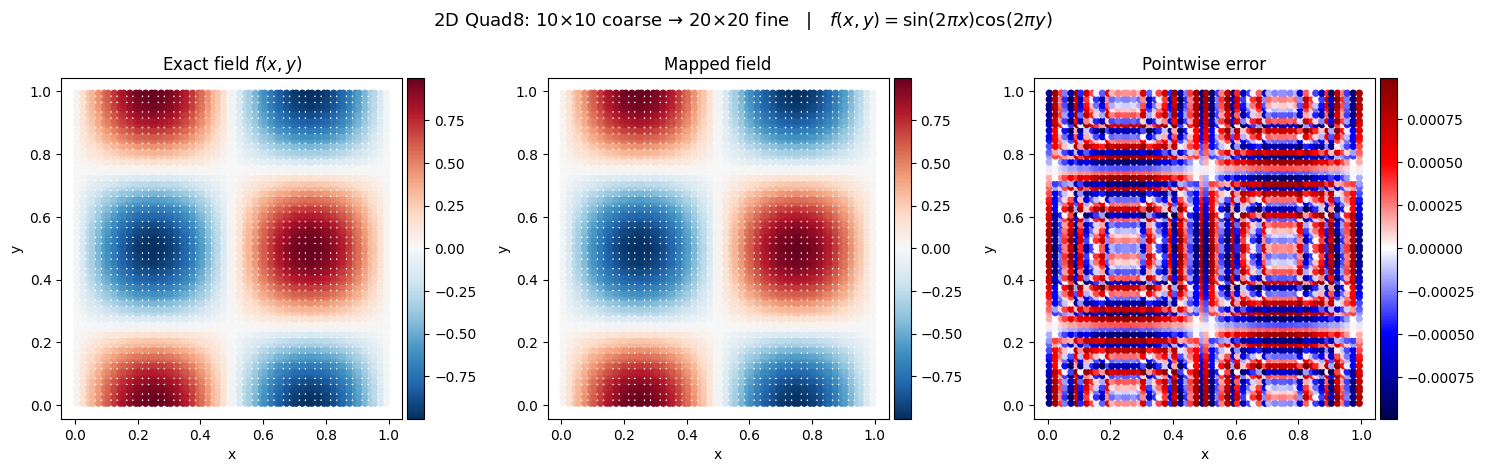

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def scatter_field(ax, pts, vals, title, cmap='RdBu_r', symm=False):
    vmax = np.max(np.abs(vals)) if symm else None
    vmin = -vmax if symm else None
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=vals, cmap=cmap,
                    s=18, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(sc, cax=cax)

scatter_field(axes[0], ipts, exact,  'Exact field $f(x,y)$')
scatter_field(axes[1], ipts, mapped, 'Mapped field')
scatter_field(axes[2], ipts, error,  'Pointwise error', cmap='seismic', symm=True)

plt.suptitle(f'2D Quad8: {nx_c}×{nx_c} coarse → {nx_f}×{nx_f} fine   |   '
             f'$f(x,y)=\\sin(2\\pi x)\\cos(2\\pi y)$', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('2d_field_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# --- Build meshes ---
nx_c, ny_c = 10, 10
nx_f, ny_f = 20, 20

nodes_c, elems_c = make_quad8_mesh(nx_c, ny_c)
nodes_f, elems_f = make_quad8_mesh(nx_f, ny_f)

f2d = lambda x, y: x+y

field_c = make_quad8_field(nodes_c, elems_c, f2d)

# --- Map ---
result = l2map_py.map_integration_points(
    nodes_f, elems_f, nodes_c, elems_c, field_c,
    element_type="Quad8", n_threads=-1
)

# --- Reference: exact field at fine integration points ---
ipts = np.array(result.ipoint_coords)   # (M*9, 2)
mapped = result.values[:, 0]            # (M*9,)
exact  = f2d(ipts[:, 0], ipts[:, 1])
error  = mapped - exact

print(f"Fine mesh: {nx_f}x{ny_f} = {nx_f*ny_f} elements, {len(mapped)} integration points")
print(f"Max abs error : {np.max(np.abs(error)):.4e}")
print(f"RMS error     : {np.sqrt(np.mean(error**2)):.4e}")

Fine mesh: 20x20 = 400 elements, 3600 integration points
Max abs error : 1.5661e-12
RMS error     : 2.7500e-13


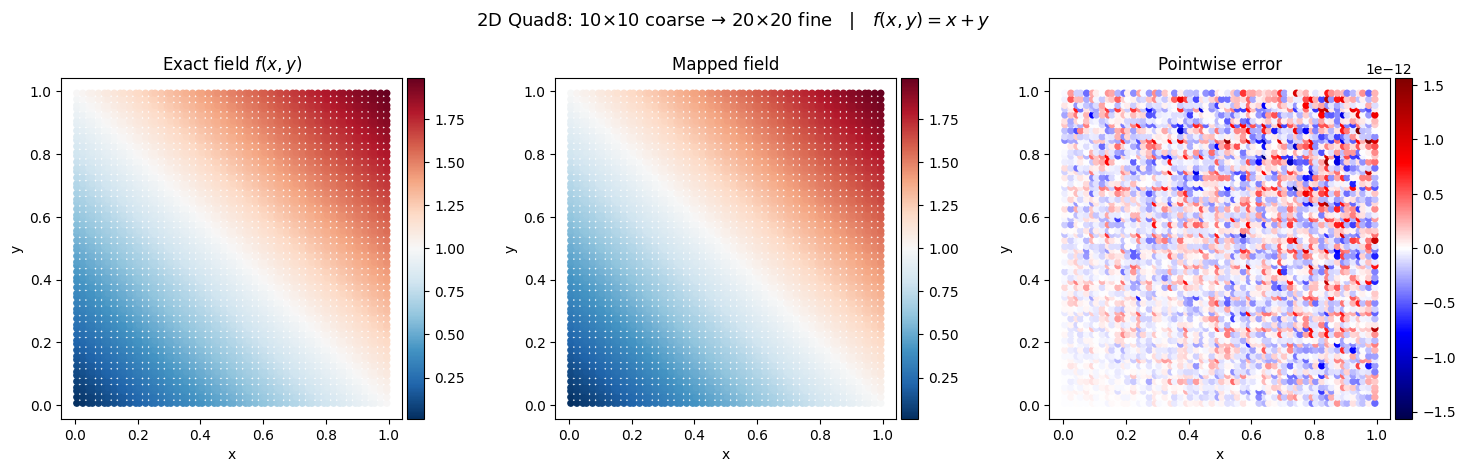

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def scatter_field(ax, pts, vals, title, cmap='RdBu_r', symm=False):
    vmax = np.max(np.abs(vals)) if symm else None
    vmin = -vmax if symm else None
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=vals, cmap=cmap,
                    s=18, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(sc, cax=cax)

scatter_field(axes[0], ipts, exact,  'Exact field $f(x,y)$')
scatter_field(axes[1], ipts, mapped, 'Mapped field')
scatter_field(axes[2], ipts, error,  'Pointwise error', cmap='seismic', symm=True)

plt.suptitle(f'2D Quad8: {nx_c}×{nx_c} coarse → {nx_f}×{nx_f} fine   |   '
             f'$f(x,y)= x+y$', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('2d_field_map_simple.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 — 2D Convergence study

Fix the coarse mesh, refine the fine mesh.  
Expect $O(h^2)$ convergence for smooth fields on linear (Quad4) and $O(h^4)$ for quadratic (Quad8) elements.

In [7]:
refinements_2d = [2, 3, 5, 7, 11, 17, 23,29, 37, 47, 59, 71, 89, 107, 131, 157, 191, 227, 263, 307]
nx_coarse = 13

nodes_c, elems_c = make_quad8_mesh(nx_coarse, nx_coarse)
field_c = make_quad8_field(nodes_c, elems_c, f2d)

conv_max, conv_rms, conv_h = [], [], []

for nx_f in refinements_2d:
    nodes_f, elems_f = make_quad8_mesh(nx_f, nx_f)
    res = l2map_py.map_integration_points(
        nodes_f, elems_f, nodes_c, elems_c, field_c,
        element_type="Quad8", n_threads=-1
    )
    ipts = np.array(res.ipoint_coords)
    mapped = res.values[:, 0]
    exact  = f2d(ipts[:, 0], ipts[:, 1])
    err = mapped - exact
    conv_max.append(np.max(np.abs(err)))
    conv_rms.append(np.sqrt(np.mean(err**2)))
    conv_h.append(1.0 / nx_f)
    print(f"  nx_fine={nx_f:3d}  h={1/nx_f:.4f}  max={conv_max[-1]:.3e}  rms={conv_rms[-1]:.3e}")

conv_h   = np.array(conv_h)
conv_max = np.array(conv_max)
conv_rms = np.array(conv_rms)

  nx_fine=  2  h=0.5000  max=9.317e-13  rms=2.839e-13
  nx_fine=  3  h=0.3333  max=1.065e-12  rms=3.095e-13
  nx_fine=  5  h=0.2000  max=1.427e-12  rms=2.889e-13
  nx_fine=  7  h=0.1429  max=1.204e-12  rms=3.087e-13
  nx_fine= 11  h=0.0909  max=1.652e-12  rms=2.768e-13
  nx_fine= 17  h=0.0588  max=1.811e-12  rms=2.840e-13
  nx_fine= 23  h=0.0435  max=2.032e-12  rms=2.905e-13
  nx_fine= 29  h=0.0345  max=2.066e-12  rms=2.779e-13
  nx_fine= 37  h=0.0270  max=1.966e-12  rms=2.850e-13
  nx_fine= 47  h=0.0213  max=2.436e-12  rms=2.804e-13
  nx_fine= 59  h=0.0169  max=2.557e-12  rms=2.766e-13
  nx_fine= 71  h=0.0141  max=2.006e-12  rms=2.763e-13
  nx_fine= 89  h=0.0112  max=2.581e-12  rms=2.921e-13
  nx_fine=107  h=0.0093  max=2.802e-12  rms=3.045e-13
  nx_fine=131  h=0.0076  max=2.575e-12  rms=2.748e-13
  nx_fine=157  h=0.0064  max=2.313e-12  rms=3.030e-13
  nx_fine=191  h=0.0052  max=3.294e-12  rms=3.000e-13
  nx_fine=227  h=0.0044  max=2.605e-12  rms=2.721e-13
  nx_fine=263  h=0.0038  max

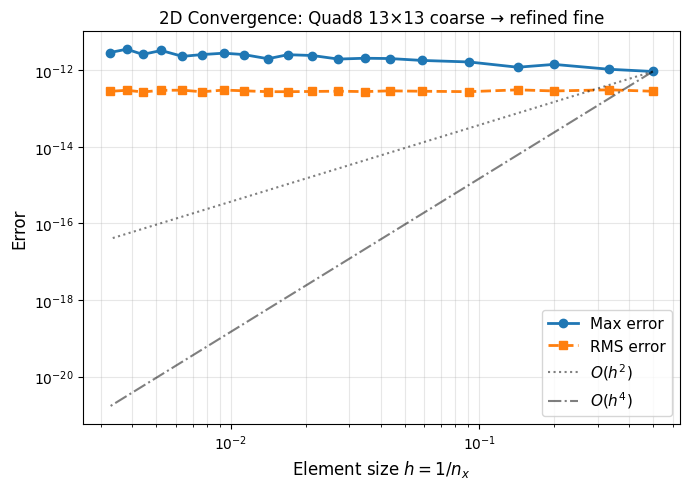

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(conv_h, conv_max, 'o-', label='Max error', linewidth=2)
ax.loglog(conv_h, conv_rms, 's--', label='RMS error', linewidth=2)

# Reference slopes
h_ref = conv_h[[0, -1]]
ax.loglog(h_ref, conv_max[0] * (h_ref / h_ref[0])**2,
          'k:', alpha=0.5, label='$O(h^2)$')
ax.loglog(h_ref, conv_max[0] * (h_ref / h_ref[0])**4,
          'k-.', alpha=0.5, label='$O(h^4)$')

ax.set_xlabel('Element size $h = 1/n_x$', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title(f'2D Convergence: Quad8 {nx_coarse}×{nx_coarse} coarse → refined fine', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('2d_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — 3D Mapping: z-slice visualization

Map a smooth 3D field on Hex8 meshes.  
Visualize a $z=0.5$ cross-section: source, mapped, and pointwise error.

In [9]:
f3d = lambda x, y, z: np.sin(2*np.pi*x) * np.cos(2*np.pi*y) * np.exp(-z)

nc = 4
nf = 8

nodes3c, elems3c = make_hex8_mesh(nc, nc, nc)
nodes3f, elems3f = make_hex8_mesh(nf, nf, nf)

field3c = make_hex8_field(nodes3c, elems3c, f3d)

t0 = time.perf_counter()
res3d = l2map_py.map_integration_points(
    nodes3f, elems3f, nodes3c, elems3c, field3c,
    element_type="Hex8", n_threads=-1
)
t_ms = (time.perf_counter() - t0) * 1000

ipts3 = np.array(res3d.ipoint_coords)  # (M*8, 3)
mapped3 = res3d.values[:, 0]
exact3  = f3d(ipts3[:,0], ipts3[:,1], ipts3[:,2])
error3  = mapped3 - exact3

print(f"Fine mesh: {nf}^3 = {nf**3} elements, {len(mapped3)} integration points")
print(f"Mapping time : {t_ms:.1f} ms")
print(f"Max abs error: {np.max(np.abs(error3)):.4e}")
print(f"RMS error    : {np.sqrt(np.mean(error3**2)):.4e}")

Fine mesh: 8^3 = 512 elements, 4096 integration points
Mapping time : 9.7 ms
Max abs error: 1.4216e-01
RMS error    : 4.0427e-02


512 points in z ≈ 0.5 slice


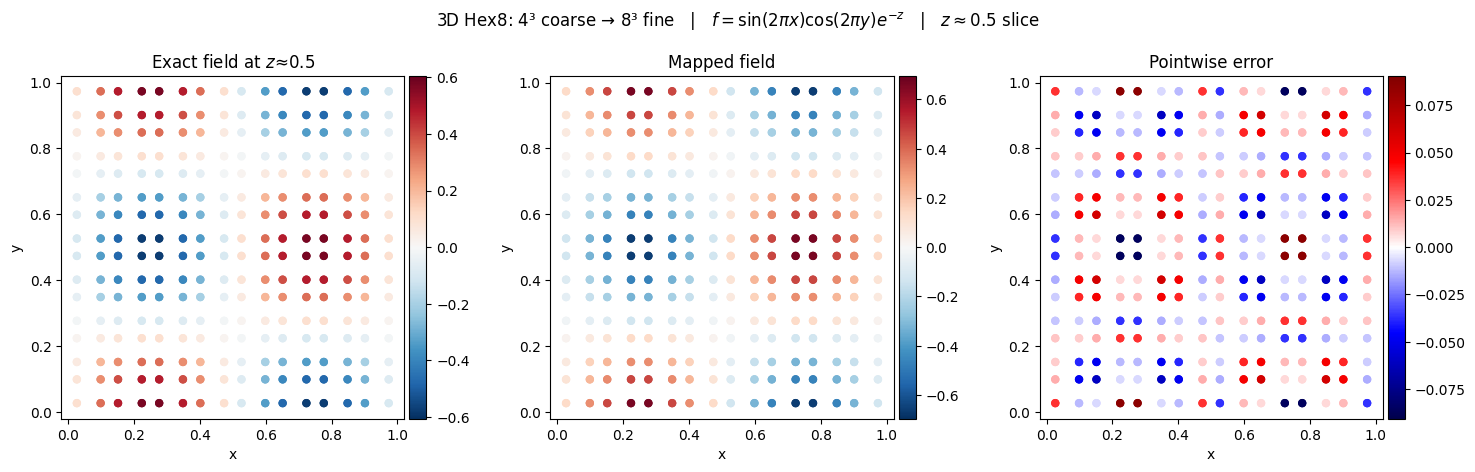

In [10]:
# Extract z ≈ 0.5 slice
z_target = 0.5
z_tol = 1.0 / (2 * nf)   # half element height
mask = np.abs(ipts3[:, 2] - z_target) < z_tol

pts_sl  = ipts3[mask]
exact_sl  = exact3[mask]
mapped_sl = mapped3[mask]
error_sl  = error3[mask]

print(f"{mask.sum()} points in z ≈ {z_target} slice")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def scatter3_slice(ax, pts, vals, title, cmap='RdBu_r', symm=False):
    vmax = np.max(np.abs(vals)) if symm else None
    vmin = -vmax if symm else None
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=vals, cmap=cmap,
                    s=25, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(sc, cax=cax)

scatter3_slice(axes[0], pts_sl, exact_sl,  f'Exact field at $z≈{z_target}$')
scatter3_slice(axes[1], pts_sl, mapped_sl, 'Mapped field')
scatter3_slice(axes[2], pts_sl, error_sl,  'Pointwise error', cmap='seismic', symm=True)

plt.suptitle(f'3D Hex8: {nc}³ coarse → {nf}³ fine   |   $f=\\sin(2\\pi x)\\cos(2\\pi y)e^{{-z}}$   |   '
             f'$z\\approx{z_target}$ slice', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('3d_slice_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Error distribution

Histogram of pointwise errors for both 2D and 3D cases.

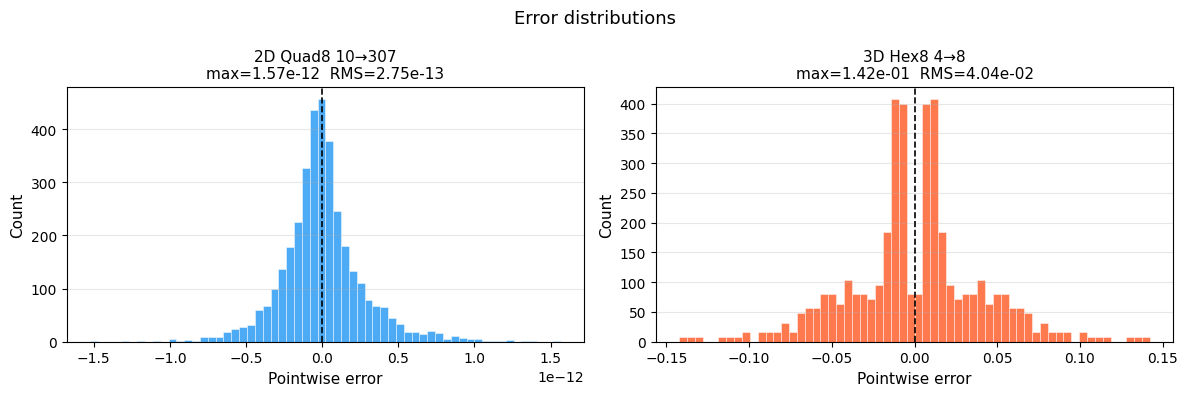

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, errs, label, color in [
    (axes[0], error,  f'2D Quad8 {nx_c}→{nx_f}', '#2196F3'),
    (axes[1], error3, f'3D Hex8 {nc}→{nf}',      '#FF5722'),
]:
    ax.hist(errs, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Pointwise error', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label}\nmax={np.max(np.abs(errs)):.2e}  RMS={np.sqrt(np.mean(errs**2)):.2e}',
                 fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Error distributions', fontsize=13)
plt.tight_layout()
plt.savefig('error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — 3D Convergence study

In [29]:
refinements_3d = [2, 4, 6, 8, 11,13, 17, 23, 29,37, 47, 59]
nc3 = 5

nodes3c, elems3c = make_hex8_mesh(nc3, nc3, nc3)
field3c = make_hex8_field(nodes3c, elems3c, f3d)

conv3_max, conv3_rms, conv3_h, conv3_t = [], [], [], []

for nf3 in refinements_3d:
    nodes3f, elems3f = make_hex8_mesh(nf3, nf3, nf3)
    t0 = time.perf_counter()
    res = l2map_py.map_integration_points(
        nodes3f, elems3f, nodes3c, elems3c, field3c,
        element_type="Hex8", n_threads=-1
    )
    t_ms = (time.perf_counter() - t0) * 1000
    ipts = np.array(res.ipoint_coords)
    mapped = res.values[:, 0]
    exact  = f3d(ipts[:,0], ipts[:,1], ipts[:,2])
    err = mapped - exact
    conv3_max.append(np.max(np.abs(err)))
    conv3_rms.append(np.sqrt(np.mean(err**2)))
    conv3_h.append(1.0 / nf3)
    conv3_t.append(t_ms)
    print(f"  nf={nf3:2d}  h={1/nf3:.3f}  max={conv3_max[-1]:.3e}  rms={conv3_rms[-1]:.3e}  t={t_ms:.0f}ms")

conv3_h   = np.array(conv3_h)
conv3_max = np.array(conv3_max)
conv3_rms = np.array(conv3_rms)
conv3_t   = np.array(conv3_t)

  nf= 2  h=0.500  max=5.379e-02  rms=3.547e-02  t=1ms
  nf= 4  h=0.250  max=4.762e-02  rms=1.281e-02  t=2ms
  nf= 6  h=0.167  max=6.324e-02  rms=1.718e-02  t=5ms
  nf= 8  h=0.125  max=9.013e-02  rms=2.158e-02  t=12ms
  nf=11  h=0.091  max=1.198e-01  rms=2.401e-02  t=26ms
  nf=13  h=0.077  max=1.283e-01  rms=2.485e-02  t=40ms
  nf=17  h=0.059  max=1.482e-01  rms=2.564e-02  t=87ms
  nf=23  h=0.043  max=1.733e-01  rms=2.614e-02  t=166ms
  nf=29  h=0.034  max=1.949e-01  rms=2.635e-02  t=312ms
  nf=37  h=0.027  max=1.979e-01  rms=2.652e-02  t=667ms
  nf=47  h=0.021  max=2.094e-01  rms=2.662e-02  t=1408ms
  nf=59  h=0.017  max=2.167e-01  rms=2.669e-02  t=2867ms


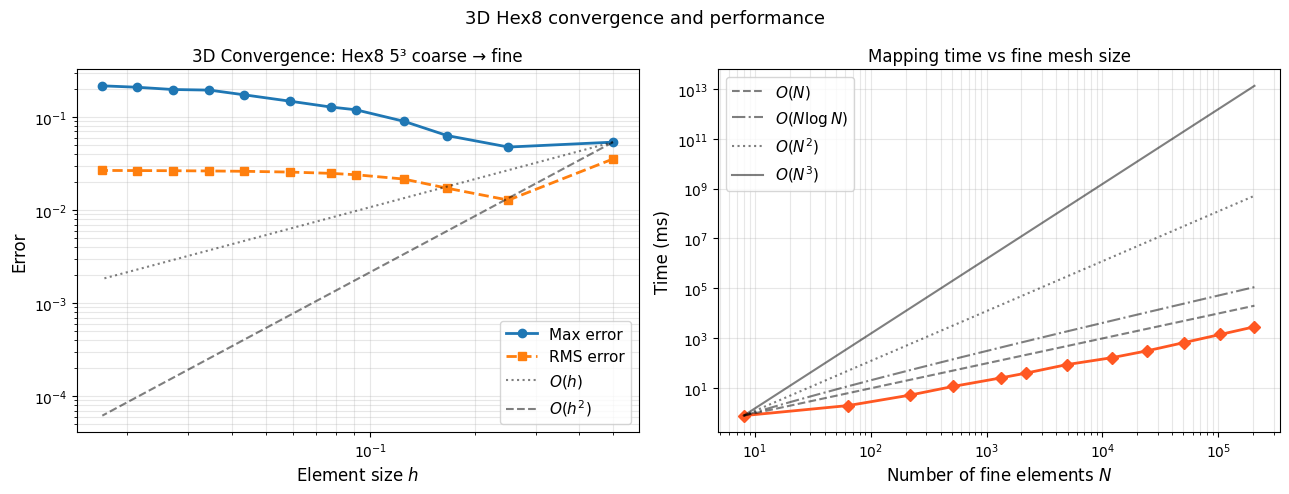

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Convergence ---
ax = axes[0]
ax.loglog(conv3_h, conv3_max, 'o-', label='Max error', linewidth=2)
ax.loglog(conv3_h, conv3_rms, 's--', label='RMS error', linewidth=2)
h_ref = conv3_h[[0, -1]]
ax.loglog(h_ref, conv3_max[0] * (h_ref/h_ref[0])**1, 'k:',  alpha=0.5, label='$O(h)$')
ax.loglog(h_ref, conv3_max[0] * (h_ref/h_ref[0])**2, 'k--', alpha=0.5, label='$O(h^2)$')
ax.set_xlabel('Element size $h$', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title(f'3D Convergence: Hex8 {nc3}³ coarse → fine', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

# --- Timing ---
ax = axes[1]
n_elems = np.array(refinements_3d)**3
ax.loglog(n_elems, conv3_t, 'D-', color='#FF5722', linewidth=2)
# Reference O(N) slope
ax.loglog(n_elems[[0,-1]],
          conv3_t[0] * (n_elems[[0,-1]] / n_elems[0]),
          'k--', alpha=0.5, label='$O(N)$')
# Reference O(N log N) curve
n_ref = np.geomspace(n_elems[0], n_elems[-1], 200)
ref_nlogn = conv3_t[0] * (n_ref / n_elems[0]) * (np.log1p(n_ref) / np.log1p(n_elems[0]))
# Reference O(N^2) curve
ref_n2 = conv3_t[0] * (n_ref / n_elems[0])**2
# Reference O(N^3) curve (for worst-case all-to-all)
ref_n3 = conv3_t[0] * (n_ref / n_elems[0])**3
ax.loglog(n_ref, ref_nlogn, 'k-.', alpha=0.5, label='$O(N \\log N)$')
ax.loglog(n_ref, ref_n2, 'k:', alpha=0.5, label='$O(N^2)$')
ax.loglog(n_ref, ref_n3, 'k-', alpha=0.5, label='$O(N^3)$')

ax.set_xlabel('Number of fine elements $N$', fontsize=12)
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_title('Mapping time vs fine mesh size', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.suptitle('3D Hex8 convergence and performance', fontsize=13)
plt.tight_layout()
plt.savefig('3d_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Linear field: identity check

A trilinear field is **exactly representable** by Hex8 elements.  
Errors should be at machine precision (~1e-12).

In [24]:
f_lin = lambda x, y, z: 1.0 + 2.0*x + 3.0*y + 4.0*z

configs = [
    (5,  10,  '1K  (5³→10³)'),
    (10, 21,  '10K (10³→21³)'),
]

lin_results = []
for nc, nf, label in configs:
    nc_nodes, nc_elems = make_hex8_mesh(nc, nc, nc)
    nf_nodes, nf_elems = make_hex8_mesh(nf, nf, nf)
    fd = make_hex8_field(nc_nodes, nc_elems, f_lin)

    t0 = time.perf_counter()
    res = l2map_py.map_integration_points(
        nf_nodes, nf_elems, nc_nodes, nc_elems, fd,
        element_type="Hex8", n_threads=-1
    )
    t_ms = (time.perf_counter() - t0) * 1000

    ipts = np.array(res.ipoint_coords)
    err = res.values[:,0] - f_lin(ipts[:,0], ipts[:,1], ipts[:,2])
    lin_results.append((label, np.max(np.abs(err)), np.sqrt(np.mean(err**2)), t_ms, err))
    print(f"{label}:  max={np.max(np.abs(err)):.3e}  rms={np.sqrt(np.mean(err**2)):.3e}  t={t_ms:.0f}ms")

1K  (5³→10³):  max=2.309e-14  rms=3.765e-15  t=15ms
10K (10³→21³):  max=1.776e-14  rms=3.177e-15  t=129ms


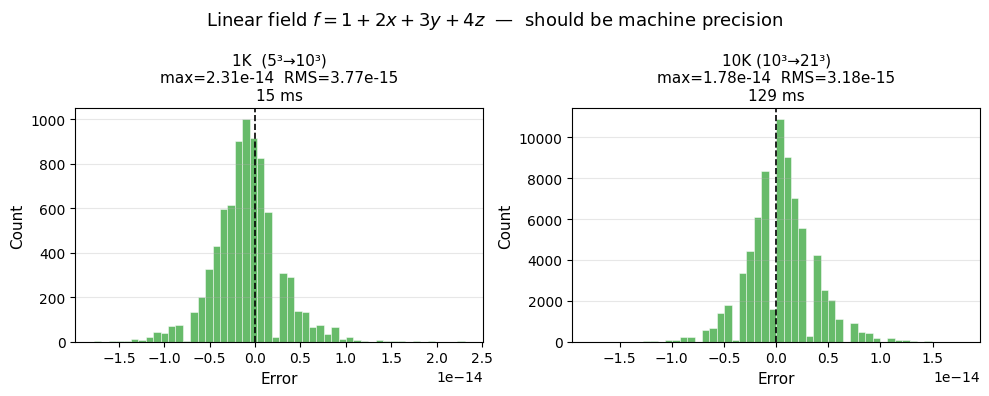

In [25]:
fig, axes = plt.subplots(1, len(lin_results), figsize=(5*len(lin_results), 4))
if len(lin_results) == 1:
    axes = [axes]

for ax, (label, max_e, rms_e, t_ms, errs) in zip(axes, lin_results):
    ax.hist(errs, bins=50, color='#4CAF50', alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Error', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{label}\nmax={max_e:.2e}  RMS={rms_e:.2e}\n{t_ms:.0f} ms', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Linear field $f=1+2x+3y+4z$  —  should be machine precision', fontsize=13)
plt.tight_layout()
plt.savefig('linear_field_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Multi-component field

Map a 3-component vector field and check each component independently.

In [26]:
# Build a multi-component field manually
def make_hex8_field_mc(nodes, elements, funcs):
    """funcs: list of callables f(x,y,z), one per component."""
    gp = 1.0 / np.sqrt(3.0)
    nat_pts = [(xi, eta, zeta)
               for zeta in [-gp, gp] for eta in [-gp, gp] for xi in [-gp, gp]]
    def shape(xi, eta, zeta):
        return 0.125 * np.array([
            (1-xi)*(1-eta)*(1-zeta), (1+xi)*(1-eta)*(1-zeta),
            (1+xi)*(1+eta)*(1-zeta), (1-xi)*(1+eta)*(1-zeta),
            (1-xi)*(1-eta)*(1+zeta), (1+xi)*(1-eta)*(1+zeta),
            (1+xi)*(1+eta)*(1+zeta), (1-xi)*(1+eta)*(1+zeta),
        ])
    node_xyz = {int(row[0]): row[1:4] for row in nodes}
    rows = []
    for elem in elements:
        eid = int(elem[0])
        nids = elem[1:].astype(int)
        coords = np.array([node_xyz[n] for n in nids])
        for ipt, (xi, eta, zeta) in enumerate(nat_pts):
            N = shape(xi, eta, zeta)
            x, y, z = N @ coords
            vals = [f(x, y, z) for f in funcs]
            rows.append([eid, ipt+1] + vals)
    return np.array(rows, dtype=float)

f_mc = [
    lambda x,y,z: x + y,
    lambda x,y,z: y + z,
    lambda x,y,z: x + z,
]

nc_m, nf_m = 3, 6
nc_nodes, nc_elems = make_hex8_mesh(nc_m, nc_m, nc_m)
nf_nodes, nf_elems = make_hex8_mesh(nf_m, nf_m, nf_m)
fd_mc = make_hex8_field_mc(nc_nodes, nc_elems, f_mc)

res_mc = l2map_py.map_integration_points(
    nf_nodes, nf_elems, nc_nodes, nc_elems, fd_mc,
    element_type="Hex8", n_threads=-1
)

ipts_mc = np.array(res_mc.ipoint_coords)
x, y, z = ipts_mc[:,0], ipts_mc[:,1], ipts_mc[:,2]
exact_mc = np.column_stack([f(x,y,z) for f in f_mc])
errs_mc = res_mc.values - exact_mc

comp_labels = ['$x+y$', '$y+z$', '$x+z$']
for i, lbl in enumerate(comp_labels):
    e = errs_mc[:,i]
    print(f"Component {i+1} ({lbl}): max={np.max(np.abs(e)):.2e}  RMS={np.sqrt(np.mean(e**2)):.2e}")

Component 1 ($x+y$): max=3.77e-15  RMS=6.56e-16
Component 2 ($y+z$): max=3.11e-15  RMS=6.38e-16
Component 3 ($x+z$): max=3.11e-15  RMS=6.58e-16


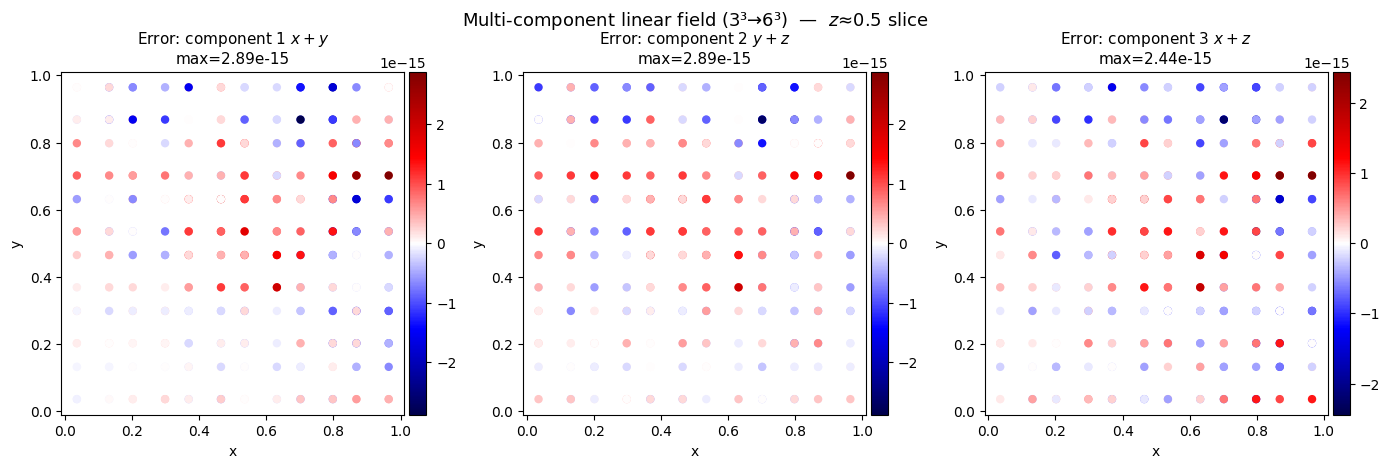

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Z ≈ 0.5 slice for multi-component
z_tol = 1.0 / (2 * nf_m)
mask_mc = np.abs(ipts_mc[:,2] - 0.5) < z_tol

for i, (ax, lbl) in enumerate(zip(axes, comp_labels)):
    e = errs_mc[mask_mc, i]
    pts = ipts_mc[mask_mc]
    vmax = max(np.max(np.abs(e)), 1e-15)
    sc = ax.scatter(pts[:,0], pts[:,1], c=e, cmap='seismic',
                    vmin=-vmax, vmax=vmax, s=25)
    ax.set_aspect('equal')
    ax.set_title(f'Error: component {i+1} {lbl}\nmax={np.max(np.abs(e)):.2e}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(sc, cax=cax)

plt.suptitle(f'Multi-component linear field ({nc_m}³→{nf_m}³)  —  $z≈0.5$ slice', fontsize=13)
plt.tight_layout()
plt.savefig('multicomp_error_slice.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Summary table

In [28]:
from IPython.display import display, HTML

rows_html = ""
for label, max_e, rms_e, t_ms, _ in lin_results:
    rows_html += f"<tr><td>3D Hex8 linear  {label}</td><td>{max_e:.2e}</td><td>{rms_e:.2e}</td><td>{t_ms:.0f} ms</td></tr>"

# Add 2D sin/cos row
rows_html += (f"<tr><td>2D Quad8 sin/cos {nx_c}→{nx_f}</td>"
              f"<td>{np.max(np.abs(error)):.2e}</td>"
              f"<td>{np.sqrt(np.mean(error**2)):.2e}</td>"
              f"<td>—</td></tr>")
rows_html += (f"<tr><td>3D Hex8 sin/cos/exp {nc}³→{nf}³</td>"
              f"<td>{np.max(np.abs(error3)):.2e}</td>"
              f"<td>{np.sqrt(np.mean(error3**2)):.2e}</td>"
              f"<td>{t_ms:.0f} ms</td></tr>")

html = f"""
<table style='border-collapse:collapse; font-family:monospace; font-size:13px'>
<thead><tr style='background:#eee'>
  <th style='padding:6px 12px; border:1px solid #ccc'>Case</th>
  <th style='padding:6px 12px; border:1px solid #ccc'>Max error</th>
  <th style='padding:6px 12px; border:1px solid #ccc'>RMS error</th>
  <th style='padding:6px 12px; border:1px solid #ccc'>Time</th>
</tr></thead>
<tbody>{rows_html}</tbody>
</table>
"""
display(HTML(html))

Case,Max error,RMS error,Time
3D Hex8 linear 1K (5³→10³),2.31e-14,3.77e-15,15 ms
3D Hex8 linear 10K (10³→21³),1.78e-14,3.18e-15,129 ms
2D Quad8 sin/cos 10→307,1.57e-12,2.75e-13,—
3D Hex8 sin/cos/exp 10³→21³,1.42e-01,4.04e-02,129 ms
